### Load dataset

In [1]:
import torch
from torch import nn, Tensor
from torchvision.transforms import v2

from src import configs as cfg
from src import models, plotting
from src import dataset, metrics, plotting

/root/repos/raidium_challenge/.venv/lib/python3.13/site-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


In [2]:
path = "unet_epoch_1750.pt"

In [3]:
chkpt = torch.load(path, weights_only=False)
train_cfg = chkpt["train_cfg"]
if "mask_rec_loss_weight" in train_cfg:
    del train_cfg["mask_rec_loss_weight"]
train_cfg = cfg.TrainingConfig(**train_cfg)
model_cfg = cfg.ModelConfig(**chkpt["model_cfg"])

model = models.mk_model_from_cfg(model_cfg)
model.load_state_dict(chkpt["model"])

<All keys matched successfully>

In [4]:
train_cfg.batch_size

64

In [5]:
loaders = dataset.mk_segmentation_data_loaders(train_cfg)

sampling method: weighted
train_dl_kwargs: {'sampler': <torch.utils.data.sampler.WeightedRandomSampler object at 0x7ef9d28dba10>, 'batch_size': 64}


In [6]:
chkpt.keys()

dict_keys(['model', 'model_cfg', 'train_cfg', 'optimizer', 'lr_scheduler', 'lr_scheduler_cfg', 'optimizer_cfg', 'step', 'epoch', 'training_samples_seen'])

torch.Size([64, 1, 256, 256])
with cropping
without transforms


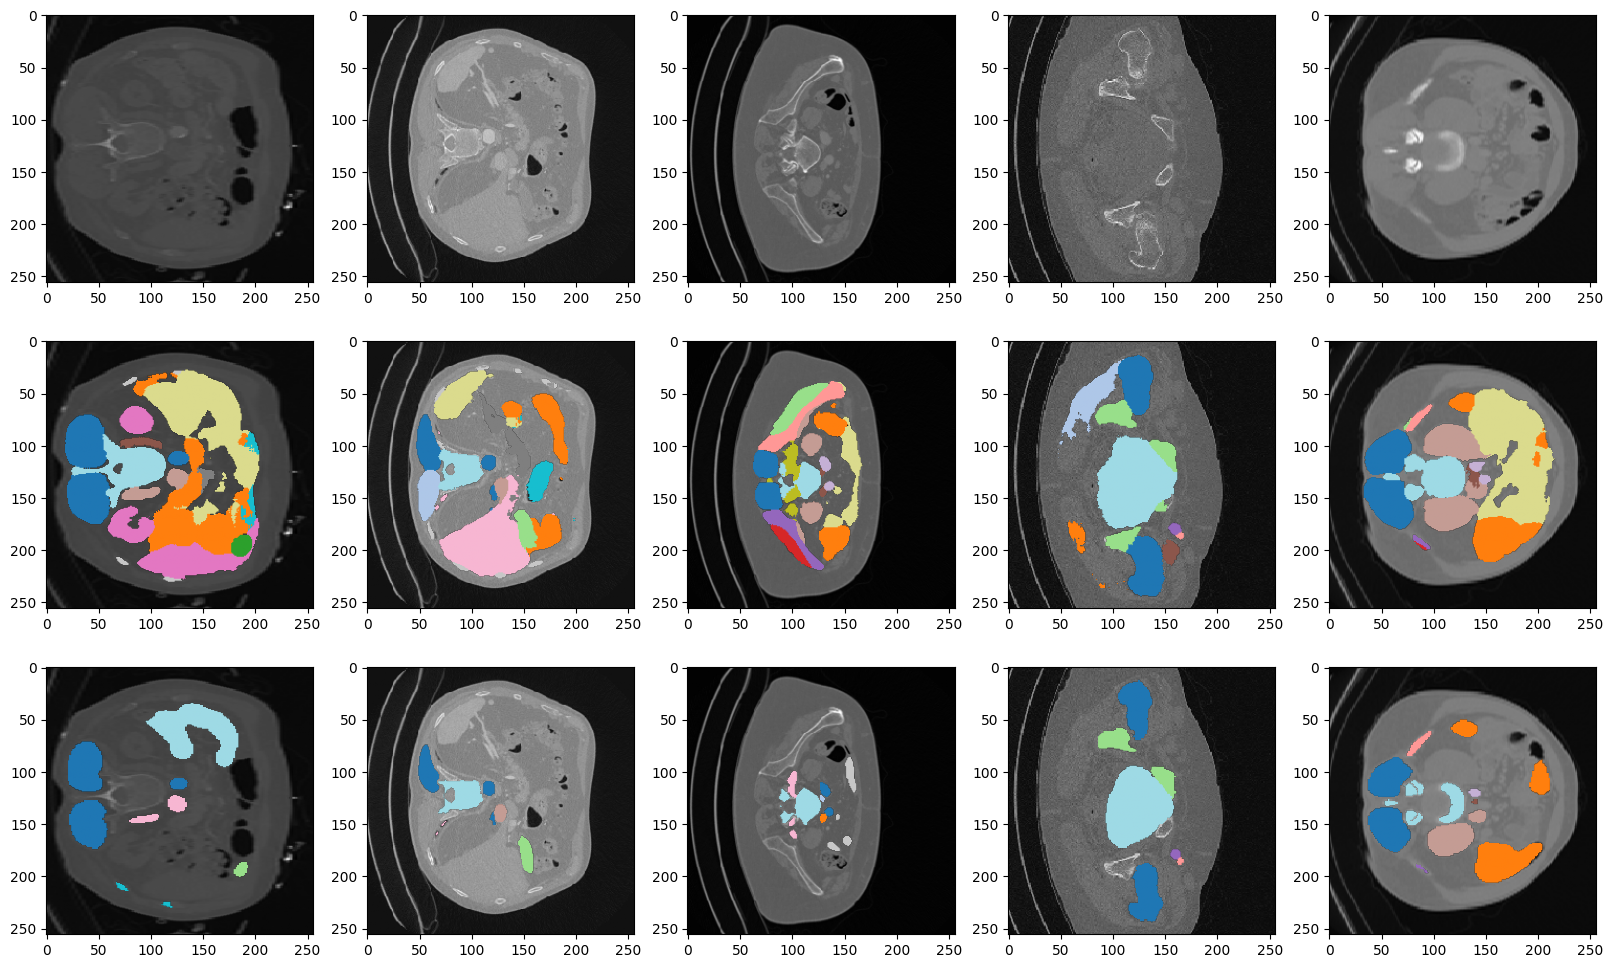

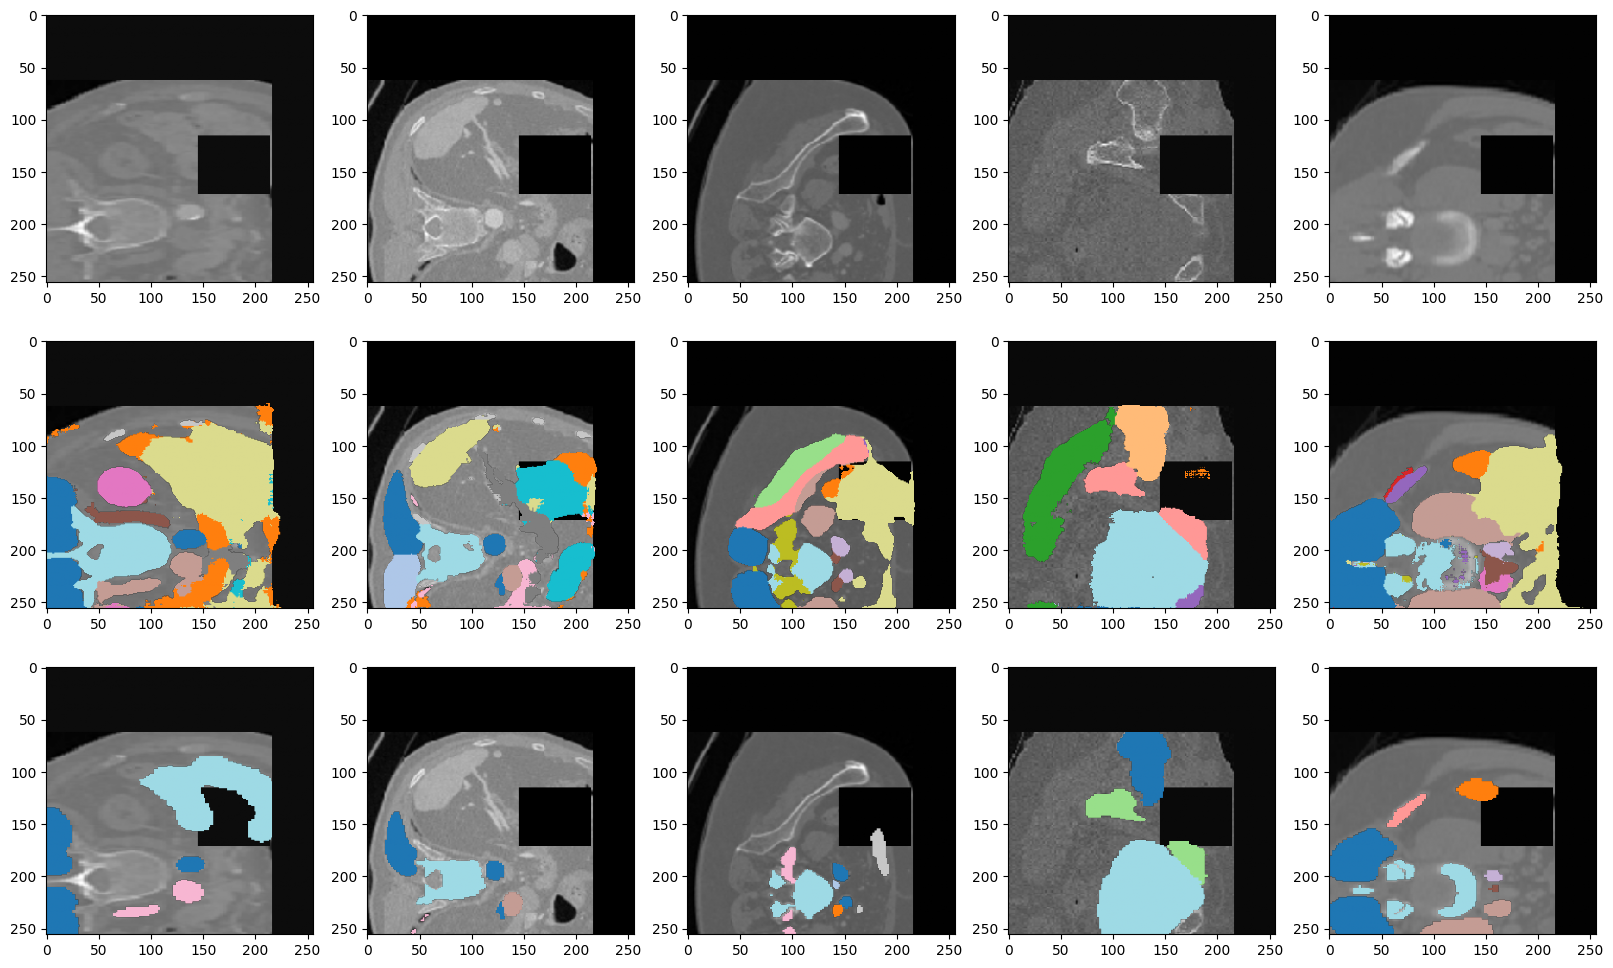

In [10]:
x, y_true = next(iter(loaders["train"]))
print(x.shape)
with torch.no_grad():
    print("with cropping")
    plotting.plt_seg_pred(model, {"x": x, "y_true": y_true}, v2.Identity())
    print("without transforms")
    plotting.plt_seg_pred(model, {"x": x, "y_true": y_true}, train_cfg.transform)

### Make submission

In [8]:
from tqdm import tqdm

import numpy as np
import pandas as pd
from torch.utils.data import DataLoader

from src import configs as cfg


*_, x_test = dataset.load_raw_dataset(cfg.DEVICE)

@torch.no_grad
def mk_submission(model: nn.Module, x_test: Tensor, batch_size: int=128):
    test_loader = DataLoader(x_test, batch_size=batch_size, shuffle=False)
    predictions = []

    for x in tqdm(test_loader) :
        x = x.to(device=cfg.DEVICE)
        batch = {'x': x}
        batch = dataset.preprocess_batch(batch)
        mode_output_dict = model(batch)
        pred = torch.argmax(mode_output_dict["y_pred"], dim=1)
        predictions.append(pred.cpu().numpy())

    predictions = np.concat(predictions)
    print("n unique values:", len(np.unique(predictions)))
    df = pd.DataFrame(predictions.reshape((predictions.shape[0], -1))).T
    df.index = [f"Pixel {i}" for i in df.index]
    df.columns = [f"{col}.png" for col in df.columns]
    df.to_csv("submission.csv")

mk_submission(model, x_test)

 50%|█████     | 2/4 [00:00<00:00,  4.18it/s]

100%|██████████| 4/4 [00:00<00:00,  4.40it/s]


n unique values: 55
